# Space-Time Utilization of Urban Roadways under Alternative Intersection Control

## Exploratory analysis of roadway occupancy from CAV microsimulation trajectories

**Author:** Milan Knezevic
**Course:** ENGR 2451 / DSCI 451  
**Date:** 2026-09-25



# Abstract

This project examines how three intersection control regimes utilize roadway space over time.
Vehicle trajectory data from the FAUSIM microsimulation platform are aggregated into a
space-time occupancy field defined on a longitudinal-lateral-time grid, and the distribution
of that field is compared across control regimes. Roadway occupancy is shown to be equivalent
to Edie's generalized traffic density, which allows the same trajectory data to yield density,
flow, and speed on a common grid. Exploratory analysis characterizes the occupancy
distributions, their dispersion, and their relationship to conventional performance measures.

# Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ---- point this at the folder holding the DB_0_* trajectory files ----
DATA_DIR = Path(".")

FILES = {
    "FT":       "DB_0_Generic_FT_LOSD_RS11_GPM.csv",
    "FRIC":     "DB_0_Generic_FRIC_LOSD_RS11_GPM.csv",
    "CADLARIC": "DB_0_Generic_CADLARIC_LOSD_RS11_GPM.csv",
}
SYSTEMS = list(FILES)
COLORS  = {"FT": "#d13b3b", "FRIC": "#3b6ed1", "CADLARIC": "#2d8a6e"}

# ---- simulation constants recovered from the network geometry (see Data Dictionary) ----
PATCH   = 0.7      # m per NetLogo patch
TICK    = 0.2      # s per simulation tick (5 Hz)
LANE_W  = 3.5      # m, = 5 patches
CELL_P  = 5        # cell length in patches -> 3.5 m longitudinal
INT_T   = 300      # measurement interval in ticks -> 60 s
LANE_CEN = np.array([-13, -8, -3, 3, 8, 13])   # arterial lane centres, patches
INTERSECTIONS = np.array([-300.0, 0.0, 300.0]) # intersection centres, patches

print("cell:", CELL_P*PATCH, "m x", LANE_W, "m   interval:", INT_T*TICK, "s")

cell: 3.5 m x 3.5 m   interval: 60.0 s


# Introduction

**Question.** How can the spatial and temporal distribution of roadway occupancy be quantified
within a single formulation, and does it differ systematically between intersection control
regimes?

**Why it matters.** Traffic control research overwhelmingly manages the *temporal* dimension of
conflicts through signal phases or reservation slots, while the spatial dimension is treated as
fixed. Occupancy is a direct proxy for traffic density, a fundamental characteristic of traffic
flow, so a generalizable space-time occupancy measure gives a control-agnostic way to evaluate
any regime, including future ones built around connected and automated vehicles.

**Data source.** Vehicle trajectories from FAUSIM (Flexible Arterial Utilization Simulation
Modeling), a NetLogo-based microsimulation platform built to model roadways used in either
direction of travel. The network is a six-lane arterial crossed by three six-lane streets 210 m
apart. Three control regimes are simulated over one hour at level of service D:

| regime | description |
|---|---|
| FT | fixed-time signal control (baseline) |
| FRIC | fully reservation-based intersection control, conventional lane assignment |
| CADLARIC | combined alternate-direction lane assignment + reservation-based control |

**Key variables.** Vehicle position (longitudinal and lateral), speed, desired speed, and
timestamp, from which the occupancy field and derived traffic quantities are constructed.

**Additional data that would improve the analysis.** Multiple random seeds (only seed 11 is used
here), additional demand levels, and the signal cycle length for the FT scenario.

# Data Science Methods

The analysis proceeds in four steps.

1. **Trajectory conditioning.** Each sample is assigned the time interval it represents and the
   longitudinal distance travelled to the next sample. This is necessary because the logging
   interval is not identical across files (see Data Cleaning).
2. **Space-time discretization.** The arterial is divided into cells of 3.5 m longitudinal by one
   lane lateral, and the hour into 60 s intervals. Each cell-interval is a space-time region.
3. **Field construction via Edie's generalized definitions.** For a region $A$ of area
   $|A| = \Delta x \, \Delta t$,

   $$k(A) = \frac{t(A)}{|A|}, \qquad q(A) = \frac{d(A)}{|A|}, \qquad v(A) = \frac{d(A)}{t(A)}$$

   where $t(A)$ is total vehicle-time and $d(A)$ total vehicle-distance inside $A$. Occupancy,
   the fraction of the interval a cell is occupied, equals $t(A)/\Delta t$ and is therefore
   proportional to density.
4. **Distributional comparison.** Occupancy and its derived quantities are summarized by
   moments, histograms, and dispersion indices, then related to performance measures.

Packages: `pandas` and `numpy` for aggregation, `matplotlib` for visualization, `scipy.stats`
for distributional statistics.# Data Science Methods

# Exploratory Data Analysis

In [3]:
def load_trajectories(path):
    """Read one trajectory file and resample it onto a uniform time grid.

    The logging interval differs between files (1.0 s for FT, 0.2 s for the
    reservation-based regimes). At 1.0 s spacing a vehicle travels about 14 m
    between samples and therefore skips four of the 3.5 m analysis cells, which
    would concentrate its time and distance into the sampled cell and leave the
    traversed cells empty. Each trajectory is linearly interpolated onto a common
    0.2 s grid before gridding so every cell traversed receives its share.

    Two distance measures are kept deliberately:
      v_path  speed along the vehicle's own path, from the logged speed. Valid
              everywhere in the network, including the north-south cross streets.
      ds      longitudinal (east-west) progress, used only for flow on the
              arterial grid, where east-west is the direction of travel.
    """
    d = pd.read_csv(path, usecols=["ticks", "vehicleID", "xcoord", "ycoord",
                                   "curSpeed", "desSpeed_AtOrigin"])
    d = d.sort_values(["vehicleID", "ticks"], kind="stable")
    raw_n = len(d)
    log_interval = d.groupby("vehicleID", sort=False).ticks.diff().mode().iloc[0] * TICK

    parts = []
    for vid, g in d.groupby("vehicleID", sort=False):
        t = g.ticks.values
        if len(t) < 2:
            continue
        tt = np.arange(t[0], t[-1] + 1)
        parts.append(pd.DataFrame({
            "vehicleID": vid,
            "ticks": tt,
            "xcoord": np.interp(tt, t, g.xcoord.values),
            "ycoord": np.interp(tt, t, g.ycoord.values),
            "curSpeed": np.interp(tt, t, g.curSpeed.values),
            "vf": g.desSpeed_AtOrigin.iloc[0] * PATCH / TICK,
        }))
    r = pd.concat(parts, ignore_index=True)

    gv = r.groupby("vehicleID", sort=False)
    r["dt"] = TICK
    r["v_path"] = r.curSpeed * PATCH / TICK                       # m/s along path
    r["ds"] = gv.xcoord.diff(-1).mul(-1).fillna(0).abs() * PATCH   # longitudinal m
    r["delay"] = r.dt * (1.0 - r.v_path / r.vf)                    # local delay, s
    return r, log_interval, raw_n


traj, log_iv = {}, {}
for s in SYSTEMS:
    traj[s], log_iv[s], raw = load_trajectories(DATA_DIR / FILES[s])
    print(f"{s:<9} raw rows {raw:>9,} -> resampled {len(traj[s]):>9,}"
          f"   logging interval {log_iv[s]:.1f} s"
          f"   vehicles {traj[s].vehicleID.nunique():>5,}")

FT        raw rows   499,229 -> resampled 2,467,345   logging interval 1.0 s   vehicles 7,200
FRIC      raw rows 1,640,332 -> resampled 1,640,332   logging interval 0.2 s   vehicles 7,200
CADLARIC  raw rows 1,432,943 -> resampled 1,432,943   logging interval 0.2 s   vehicles 7,200


## Explanation of the dataset

Each row is one observation of one vehicle at one instant. Across the three files there are
roughly 3.5 million rows describing 7,200 vehicles per regime over one simulated hour.
All variables are numeric; `origin`, `destination` and `nextSignalID` are categorical codes.

### Data dictionary

| variable | description | type | units | range |
|---|---|---|---|---|
| `ticks` | simulation timestamp | int | ticks (1 tick = 0.2 s) | 11 - 18,705 |
| `vehicleID` | unique vehicle identifier | int | - | 1 - 7,200 |
| `xcoord` | longitudinal position (east-west) | int | patches (1 patch = 0.7 m) | -598 - 598 |
| `ycoord` | lateral position (north-south) | int | patches | -198 - 198 |
| `curSpeed` | instantaneous speed | float | patches/tick | 0 - 4.0 |
| `desSpeed_AtOrigin` | vehicle's desired (free-flow) speed | float | patches/tick | 3.2 - 4.0 |
| `nextSignalID` | next intersection on the path | int | - | 1, 2, 3 |
| `origin`, `destination` | OD node codes | int | - | 1 - 8 |

**Derived variables**

| variable | description | units |
|---|---|---|
| `dt` | time represented by the sample | s |
| `ds` | longitudinal distance to next sample | m |
| `v` | realized speed, `ds/dt` | m/s |
| `vf` | free-flow speed of that vehicle | m/s |
| `delay` | local delay, `dt - ds/vf` | s |

**Unit calibration.** The patch and tick sizes are not stated in the output files and were
recovered from the network geometry: arterial lane centres sit 5 patches apart and lanes are
3.5 m wide, giving 0.7 m per patch; the one-hour run spans about 18,000 ticks, giving 0.2 s per
tick. These two constants are confirmed below by an independent conservation check.

The dataset is well suited to the proposed analysis because it records full trajectories rather
than pre-aggregated detector measurements, so the occupancy field can be constructed at any
spatial and temporal resolution rather than being fixed by the data.

In [4]:
display(traj["CADLARIC"].head())
display(traj["CADLARIC"].describe().T.round(3))

,vehicleID,ticks,xcoord,ycoord,curSpeed,vf,dt,v_path,ds,delay
0,1,11,-573.0,-8.0,3.9,13.65,0.2,13.65,2.8,0.0
1,1,12,-569.0,-8.0,3.9,13.65,0.2,13.65,2.8,0.0
2,1,13,-565.0,-8.0,3.9,13.65,0.2,13.65,2.8,0.0
3,1,14,-561.0,-8.0,3.9,13.65,0.2,13.65,2.8,0.0
4,1,15,-557.0,-8.0,3.9,13.65,0.2,13.65,2.8,0.0


,count,mean,std,min,25%,50%,75%,max
vehicleID,1432943.0,3593.000,2067.914,1.000,1803.0,3592.00,5387.000,7200.0
ticks,1432943.0,9092.371,5151.933,11.000,4618.0,9173.00,13596.000,18282.0
xcoord,1432943.0,5.361,302.259,-598.000,-297.0,3.00,297.000,598.0
ycoord,1432943.0,0.064,72.332,-198.000,-8.0,0.00,10.000,198.0
curSpeed,1432943.0,3.052,0.852,0.000,2.8,3.30,3.600,4.0
vf,1432943.0,12.472,0.810,11.200,11.9,12.60,13.300,14.0
dt,1432943.0,0.200,0.000,0.200,0.2,0.20,0.200,0.2
v_path,1432943.0,10.682,2.982,0.000,9.8,11.55,12.600,14.0
ds,1432943.0,1.191,1.167,0.000,0.0,1.40,2.100,2.8
delay,1432943.0,0.028,0.047,-0.006,0.0,0.00,0.042,0.2


## Data Cleaning

Four cleaning decisions were required.

**1. Non-uniform logging interval (most consequential).** The FT trajectories are logged every
5 ticks (1.0 s) while FRIC and CADLARIC are logged every tick (0.2 s) (I will rerun the experiments with the 0.2 tick but now this is a solution for the report).

**2. Lateral versus longitudinal distance.** On the north-south cross streets the roles of the
`xcoord` and `ycoord` axes are exchanged. Using Euclidean step distance therefore mixes
longitudinal progress with lateral movement, and during a lane change it makes distance
travelled exceed longitudinal progress, producing spurious *negative* local delay. Distance is
measured as longitudinal progress only, and the analysis grid is restricted to the east-west
arterial (`|ycoord| <= 16` patches).

**3. Per-vehicle free-flow reference.** Desired speed varies between vehicles (3.2 - 4.0
patches/tick). Using a fleet mean would assign spurious negative delay to fast vehicles, so
`desSpeed_AtOrigin` is used per vehicle.

**4. Single-sample trajectories.** Vehicles with fewer than two logged samples cannot be
interpolated and are dropped. This affects a negligible number of vehicles, reported above.

The conservation check below confirms the corrections: total vehicle-distance should be
essentially identical across regimes (the OD demand is the same) while vehicle-time should
differ substantially, and the recovered delays should match the independently reported
simulation results.

In [5]:
# Conservation check: do the derived quantities reproduce known totals?
rows = []
for s in SYSTEMS:
    d = traj[s]
    per = d.groupby("vehicleID").agg(tau=("dt", "sum"),
                                     path=("v_path", lambda x: (x * TICK).sum()),
                                     delay=("delay", "sum"))
    rows.append({
        "system": s,
        "orig. logging interval [s]": log_iv[s],
        "vehicles": len(per),
        "t(A) total veh-time [veh-s]": per.tau.sum(),
        "d(A) total path distance [veh-km]": per.path.sum() / 1000,
        "mean trip time [s]": per.tau.mean(),
        "mean path distance [m]": per.path.mean(),
        "avg delay [s/veh]": per.delay.mean(),
    })
conservation = pd.DataFrame(rows).set_index("system")
display(conservation.round(2))

dcol, tcol = "d(A) total path distance [veh-km]", "t(A) total veh-time [veh-s]"
print(f"\nTotal path distance varies by only "
      f"{100*conservation[dcol].std()/conservation[dcol].mean():.1f}% across regimes, "
      "as expected for identical OD demand,")
print(f"while total vehicle-time varies by "
      f"{100*conservation[tcol].std()/conservation[tcol].mean():.1f}%.")

,orig. logging interval [s],vehicles,t(A) total veh-time [veh-s],d(A) total path distance [veh-km],mean trip time [s],mean path distance [m],avg delay [s/veh]
system,,,,,,,
FT,1.0,7200,493469.0,3025.51,68.54,420.21,34.76
FRIC,0.2,7200,328066.4,3071.52,45.56,426.60,11.29
CADLARIC,0.2,7200,286588.6,3061.33,39.80,425.18,5.64



Total path distance varies by only 0.8% across regimes, as expected for identical OD demand,
while total vehicle-time varies by 29.6%.


Note the identity being used here: since delay is $\tau_i - d_i/v_f$ summed over vehicles,

$$D = t(A) - \frac{d(A)}{v_f}$$

so total delay is fully determined by the same two quantities that define the occupancy field.

## Constructing the space-time occupancy field

In [18]:
def occupancy_field(d, cell_p=CELL_P, int_t=INT_T):
    """Aggregate trajectories into a (lane, longitudinal cell, time interval) field.

    Returns one row per cell-interval with Edie's density, flow and speed, occupancy,
    delay, and distance to the nearest intersection.
    """
    a = d[d.ycoord.abs() <= 16].copy()                  # east-west arterial only
    lat = np.abs(a.ycoord.values[:, None] - LANE_CEN[None, :])
    a["lane"] = lat.argmin(axis=1)                      # nearest lane centre
    a["xb"] = (a.xcoord // cell_p).astype(int)          # longitudinal cell index
    a["tb"] = (a.ticks // int_t).astype(int)            # time interval index

    area = (cell_p * PATCH) * (int_t * TICK)            # |A| in m.s
    f = (a.groupby(["lane", "xb", "tb"], sort=False)
           .agg(t_A=("dt", "sum"), d_A=("ds", "sum"),
                delay=("delay", "sum"), n=("dt", "size"))
           .reset_index())

    f["occupancy"] = f.t_A / (int_t * TICK) * 100        # % of interval occupied
    f["k"] = f.t_A / area * 1000                         # veh/km
    f["q"] = f.d_A / area * 3600                         # veh/h
    f["v"] = np.where(f.t_A > 0, f.d_A / f.t_A, np.nan)  # m/s
    f["x_m"] = (f.xb * cell_p + cell_p / 2) * PATCH      # cell centre, m
    f["dist_int"] = np.abs(f.x_m.values[:, None]
                           - INTERSECTIONS[None, :] * PATCH).min(axis=1)
    f["minute"] = f.tb * int_t * TICK / 60
    return f


field = {s: occupancy_field(traj[s]) for s in SYSTEMS}
for s in SYSTEMS:
    print(f"{s:<9} occupied cell-intervals: {len(field[s]):>7,}")

display(field["CADLARIC"].head())

FT        occupied cell-intervals:  84,082
FRIC      occupied cell-intervals:  84,096
CADLARIC  occupied cell-intervals:  81,539


,lane,xb,tb,t_A,d_A,delay,n,occupancy,k,q,v,x_m,dist_int,minute
0,1,-115,0,1.2,16.1,0.0,6,2.000000,5.714286,276.0,13.416667,-400.75,190.75,0.0
1,1,-114,0,1.4,17.5,0.0,7,2.333333,6.666667,300.0,12.500000,-397.25,187.25,0.0
2,1,-113,0,1.6,21.7,0.0,8,2.666667,7.619048,372.0,13.562500,-393.75,183.75,0.0
3,1,-112,0,1.0,12.6,0.0,5,1.666667,4.761905,216.0,12.600000,-390.25,180.25,0.0
4,1,-111,0,0.8,11.2,0.0,4,1.333333,3.809524,192.0,14.000000,-386.75,176.75,0.0


# Basic statistics of the occupancy field

In [7]:
summary = pd.DataFrame({
    s: field[s][["occupancy", "k", "q", "v"]].describe().loc[
        ["mean", "std", "50%", "75%", "max"]].stack()
    for s in SYSTEMS
}).T
summary.columns = [f"{a} ({b})" for a, b in summary.columns]
print("Occupancy [%], density k [veh/km/lane], flow q [veh/h/lane], speed v [m/s]")
display(summary.round(2))

Occupancy [%], density k [veh/km/lane], flow q [veh/h/lane], speed v [m/s]


,mean (occupancy),mean (k),mean (q),mean (v),std (occupancy),std (k),std (q),std (v),50% (occupancy),50% (k),50% (q),50% (v),75% (occupancy),75% (k),75% (q),75% (v),max (occupancy),max (k),max (q),max (v)
FT,5.66,16.16,350.69,9.84,9.24,26.41,207.26,6.82,3.67,10.48,355.2,11.39,5.33,15.24,489.6,12.13,94.67,270.48,3657.6,830.2
FRIC,3.90,11.15,349.56,10.37,3.44,9.84,193.55,3.28,3.33,9.52,348.0,11.81,5.00,14.29,492.0,12.50,62.33,178.10,1236.0,14.0
CADLARIC,3.49,9.96,358.84,11.07,3.40,9.72,293.62,2.88,2.33,6.67,252.0,12.03,5.33,15.24,576.0,12.60,80.33,229.52,1584.0,14.0


In [8]:
# moments and dispersion of the occupancy distribution
from scipy import stats

rows = []
for s in SYSTEMS:
    o = field[s].occupancy.values
    rows.append({
        "system": s,
        "mean [%]": o.mean(),
        "std [%]": o.std(),
        "CoV": o.std() / o.mean(),
        "skewness": stats.skew(o),
        "kurtosis": stats.kurtosis(o, fisher=False),
        "p95 / p50": np.percentile(o, 95) / np.percentile(o, 50),
        "max [%]": o.max(),
    })
moments = pd.DataFrame(rows).set_index("system")
display(moments.round(3))

,mean [%],std [%],CoV,skewness,kurtosis,p95 / p50,max [%]
system,,,,,,,
FT,5.656,9.242,1.634,4.686,28.644,5.273,94.667
FRIC,3.901,3.443,0.883,4.200,37.823,2.800,62.333
CADLARIC,3.487,3.402,0.976,3.434,33.654,3.857,80.333


# Data Visualizations

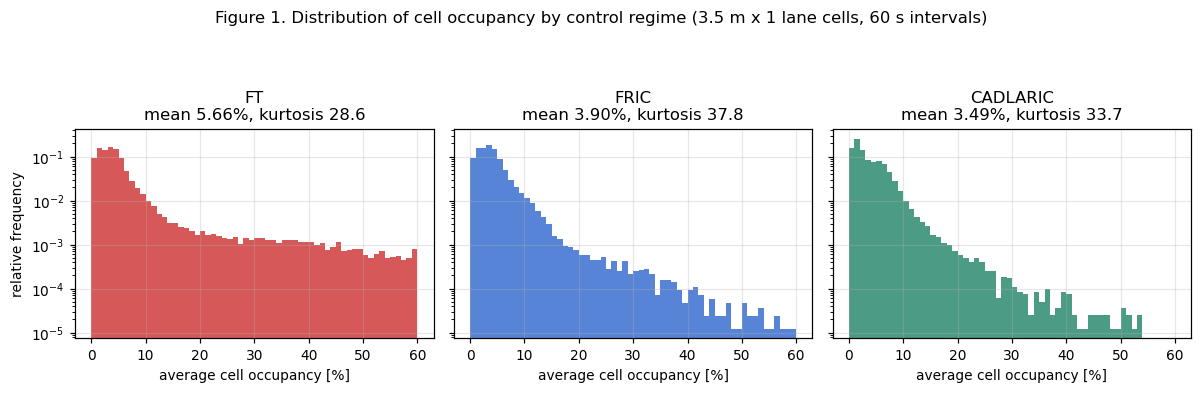

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
bins = np.arange(0, 60.5, 1.0)          # 1% occupancy bins
for ax, s in zip(axes, SYSTEMS):
    o = field[s].occupancy
    ax.hist(o, bins=bins, color=COLORS[s], alpha=0.85,
            weights=np.ones(len(o)) / len(o))
    ax.set_yscale("log")
    ax.set_title(f"{s}\nmean {o.mean():.2f}%, kurtosis {stats.kurtosis(o, fisher=False):.1f}")
    ax.set_xlabel("average cell occupancy [%]")
axes[0].set_ylabel("relative frequency")
fig.suptitle("Figure 1. Distribution of cell occupancy by control regime "
             "(3.5 m x 1 lane cells, 60 s intervals)", y=1.10)
plt.show()

All three distributions are heavy-tailed and right-skewed: most cells are lightly occupied
while a small number carry very high occupancy. The regimes differ in both the location and the
weight of that tail. Fixed-time control has both the highest mean occupancy and the heaviest
tail, consistent with vehicles queueing in a small number of cells near the stop bar. CADLARIC
has the lowest mean and the lightest tail.

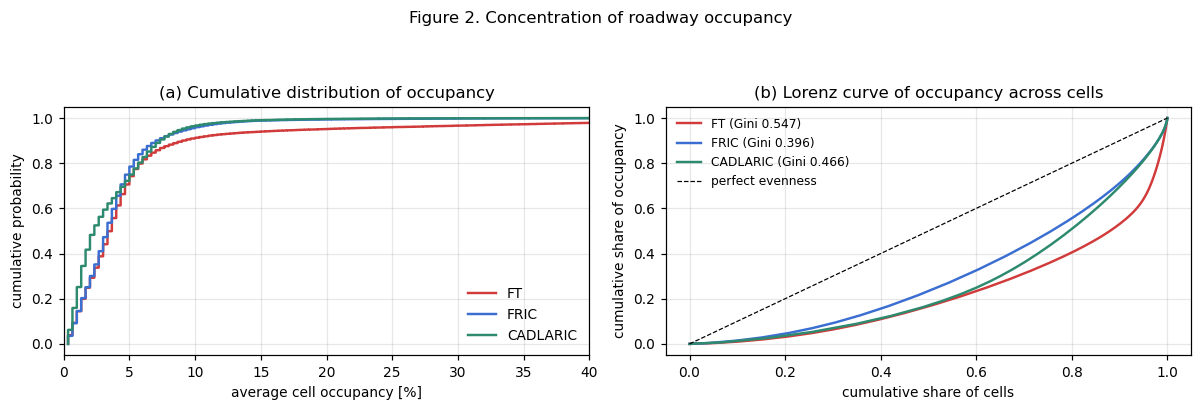

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

# empirical CDF
for s in SYSTEMS:
    o = np.sort(field[s].occupancy.values)
    ax[0].plot(o, np.arange(1, len(o) + 1) / len(o), color=COLORS[s], label=s, lw=1.6)
ax[0].set_xlim(0, 40); ax[0].set_xlabel("average cell occupancy [%]")
ax[0].set_ylabel("cumulative probability"); ax[0].legend(frameon=False)
ax[0].set_title("(a) Cumulative distribution of occupancy")

# Lorenz curve: how concentrated is occupancy across cells?
for s in SYSTEMS:
    o = np.sort(field[s].occupancy.values)
    cum = np.cumsum(o) / o.sum()
    frac = np.arange(1, len(o) + 1) / len(o)
    trapz = getattr(np, "trapezoid", None) or np.trapz
    gini = 1 - 2 * trapz(cum, frac)
    ax[1].plot(frac, cum, color=COLORS[s], lw=1.6, label=f"{s} (Gini {gini:.3f})")
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect evenness")
ax[1].set_xlabel("cumulative share of cells")
ax[1].set_ylabel("cumulative share of occupancy")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("(b) Lorenz curve of occupancy across cells")

fig.suptitle("Figure 2. Concentration of roadway occupancy", y=1.08)
plt.show()

The Lorenz curves quantify how unevenly occupancy is spread across the network. A curve on the
diagonal would mean every cell is equally occupied. All three regimes are far from that, but the
ordering is consistent: the regime with the lowest Gini coefficient distributes occupancy most
evenly across the available roadway.

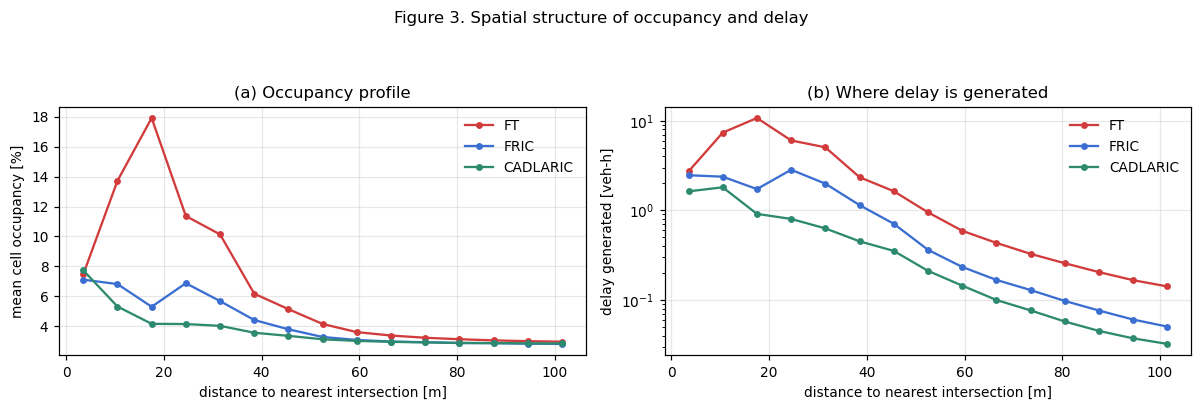

In [13]:
# spatial profile: how does occupancy decay away from the intersection?
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
edges = np.arange(0, 108, 7)
ctr = (edges[:-1] + edges[1:]) / 2
for s in SYSTEMS:
    f = field[s]
    b = pd.cut(f.dist_int, edges, labels=False)
    ax[0].plot(ctr, f.groupby(b).occupancy.mean(), "o-", color=COLORS[s],
               label=s, ms=3.5, lw=1.5)
    ax[1].plot(ctr, f.groupby(b).delay.sum() / 3600, "o-", color=COLORS[s],
               label=s, ms=3.5, lw=1.5)
ax[0].set_xlabel("distance to nearest intersection [m]")
ax[0].set_ylabel("mean cell occupancy [%]")
ax[0].legend(frameon=False); ax[0].set_title("(a) Occupancy profile")
ax[1].set_xlabel("distance to nearest intersection [m]")
ax[1].set_ylabel("delay generated [veh-h]")
ax[1].set_yscale("log"); ax[1].legend(frameon=False)
ax[1].set_title("(b) Where delay is generated")
fig.suptitle("Figure 3. Spatial structure of occupancy and delay", y=1.08)
plt.show()

Occupancy is highest immediately upstream of the intersection and decays along the link for all
three regimes, but the gradient differs sharply. Panel (b) shows that delay is generated almost
entirely within a short distance of the intersection regardless of control regime, which is a
useful negative result: the regimes differ far more in the *magnitude* of near-intersection
delay than in its spatial location.

/software/rhel9/manual/install/python/ondemand-jupyter-python3.11-2023.09/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


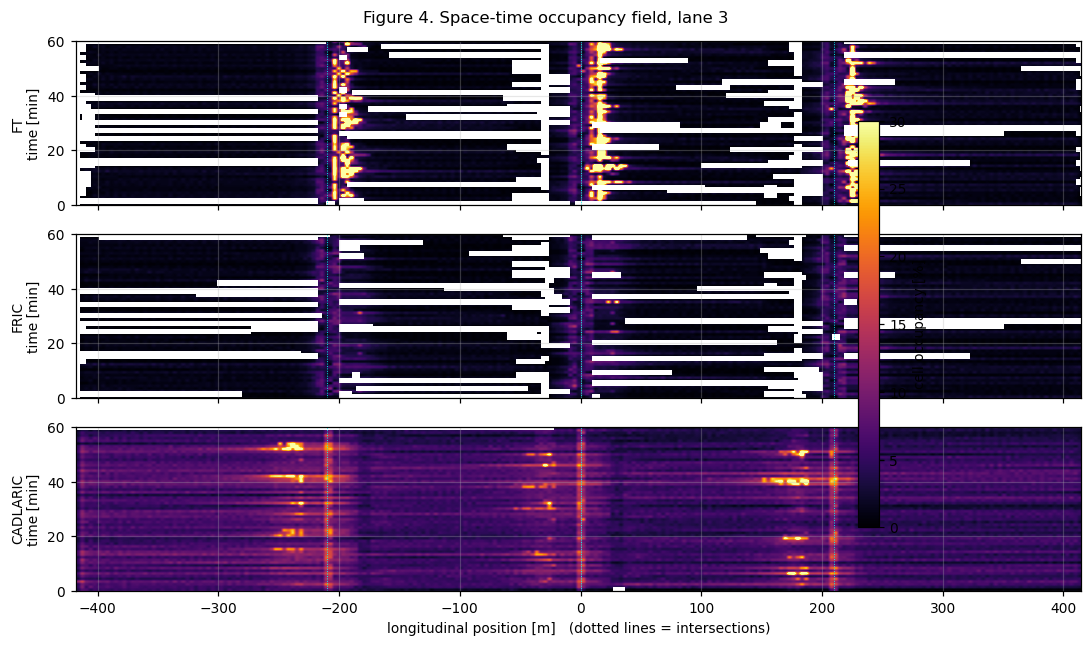

In [15]:
# code still has some issues
# occupancy heatmap over space and time for one lane
LANE = 3   # a through lane in the eastbound direction
fig, axes = plt.subplots(len(SYSTEMS), 1, figsize=(10, 6), sharex=True, sharey=True)
for ax, s in zip(axes, SYSTEMS):
    f = field[s]
    sub = f[f.lane == LANE]
    piv = sub.pivot_table(index="minute", columns="x_m",
                          values="occupancy", aggfunc="mean")
    im = ax.imshow(piv.values, aspect="auto", origin="lower", cmap="inferno",
                   vmin=0, vmax=30,
                   extent=[piv.columns.min(), piv.columns.max(),
                           piv.index.min(), piv.index.max()])
    ax.set_ylabel(f"{s}\ntime [min]")
    for xi in INTERSECTIONS * PATCH:
        ax.axvline(xi, color="cyan", lw=0.6, ls=":")
axes[-1].set_xlabel("longitudinal position [m]   (dotted lines = intersections)")
fig.colorbar(im, ax=axes, label="cell occupancy [%]", shrink=0.8)
fig.suptitle(f"Figure 4. Space-time occupancy field, lane {LANE}", y=0.97)
plt.show()

This is the space-time occupancy field itself, sliced to a single lane. Vertical bright bands
indicate cells that remain highly occupied over time, i.e. persistent queues. The fixed-time
panel shows strong banding at the stop bars; the reservation-based regimes spread occupancy more
thinly along the link.

## Variable Correlations

Two relationships are examined. First, whether occupancy alone determines the operational state
of a cell. Second, how the dispersion of the occupancy field relates to performance.

An important caution applies to the second relationship. Because total delay satisfies
$D = t(A) - d(A)/v_f$ exactly, and occupancy is proportional to $t(A)$, a regression of total
delay on mean occupancy is an algebraic identity rather than an empirical finding. Any
correlation reported below is therefore interpreted as a *decomposition* of where and how delay
arises, not as evidence of prediction.

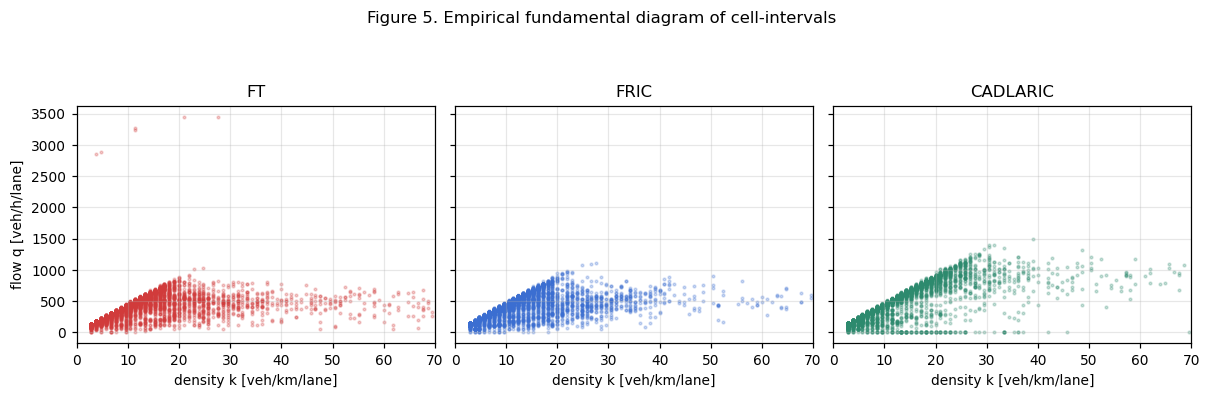

Cells held in a narrow occupancy band, range of flow and speed observed:

FT        n=278    q:     84 -    845 veh/h   v:   0.4 -   4.0 m/s
FRIC      n=92     q:    180 -    864 veh/h   v:   0.8 -   4.3 m/s
CADLARIC  n=84     q:      0 -   1212 veh/h   v:   0.0 -   5.8 m/s


In [16]:
# Does occupancy determine the operational state of a cell?
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3), sharex=True, sharey=True)
for ax, s in zip(axes, SYSTEMS):
    f = field[s][field[s].occupancy > 1].sample(min(6000, len(field[s])), random_state=0)
    ax.scatter(f.k, f.q, s=3, alpha=0.25, color=COLORS[s])
    ax.set_title(s); ax.set_xlabel("density k [veh/km/lane]")
    ax.set_xlim(0, 70)
axes[0].set_ylabel("flow q [veh/h/lane]")
fig.suptitle("Figure 5. Empirical fundamental diagram of cell-intervals", y=1.08)
plt.show()

# same occupancy, different state?
print("Cells held in a narrow occupancy band, range of flow and speed observed:\n")
for s in SYSTEMS:
    f = field[s]
    band = f[(f.occupancy > 19) & (f.occupancy < 21)]
    if len(band) < 20:
        continue
    print(f"{s:<9} n={len(band):<6} q: {band.q.min():>6.0f} - {band.q.max():>6.0f} veh/h"
          f"   v: {band.v.min():>5.1f} - {band.v.max():>5.1f} m/s")

At a fixed occupancy, flow and speed span nearly their whole range. A cell at 20% occupancy may
be a standing queue at zero flow or a platoon discharging near capacity. This is expected, since
occupancy is proportional to density and density alone does not distinguish the free-flow branch
of the fundamental diagram from the congested branch. It motivates reporting the density-flow
pair rather than occupancy alone.

,harmonic mean speed [m/s],% time stopped <0.5,% time crawl 0.5-2,% time slow 2-5,% time mid 5-9,% time free >9,% delay from stops
system,,,,,,,
FT,6.13,27.91,6.70,12.20,12.53,40.67,54.92
FRIC,9.36,4.06,0.93,13.50,17.64,63.86,16.37
CADLARIC,10.68,1.58,0.41,4.19,14.59,79.23,11.11


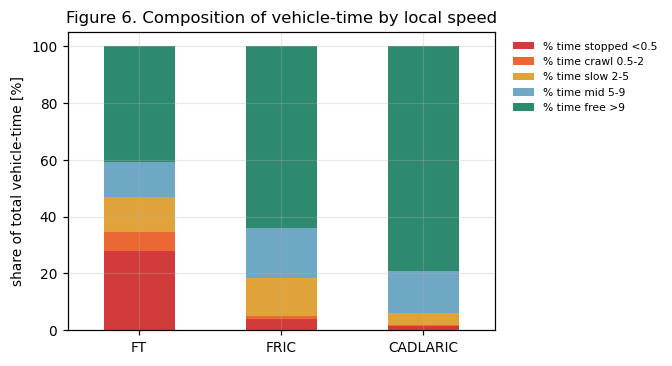

In [17]:
# where does vehicle-time accumulate, by speed along the vehicle's own path?
bands  = [(-0.01, 0.5), (0.5, 2), (2, 5), (5, 9), (9, 99)]
labels = ["stopped <0.5", "crawl 0.5-2", "slow 2-5", "mid 5-9", "free >9"]
rows = []
for s in SYSTEMS:
    d = traj[s]
    tot = d.dt.sum()
    r = {"system": s,
         "harmonic mean speed [m/s]": (d.v_path * d.dt).sum() / tot}
    for (lo, hi), lab in zip(bands, labels):
        m = (d.v_path > lo) & (d.v_path <= hi)
        r[f"% time {lab}"] = 100 * d.dt[m].sum() / tot
    stopped = d.v_path <= 0.5
    r["% delay from stops"] = 100 * d.delay[stopped].sum() / d.delay.sum()
    rows.append(r)
speed_bands = pd.DataFrame(rows).set_index("system")
display(speed_bands.round(2))

ax = speed_bands[[f"% time {l}" for l in labels]].plot(
    kind="bar", stacked=True, figsize=(6.2, 3.4),
    color=["#d13b3b", "#eb6834", "#e0a33a", "#6ea8c4", "#2d8a6e"])
ax.set_ylabel("share of total vehicle-time [%]")
ax.set_xlabel("")
ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1.02, 1))
ax.set_title("Figure 6. Composition of vehicle-time by local speed")
plt.xticks(rotation=0)
plt.show()

This decomposition explains the delay differences mechanically. Total travel time is
$\sum_{\text{cells}} d/v$, so it is governed by the distance-weighted *harmonic* mean of local
speed, which is dominated by its smallest terms. Cells where speed approaches zero contribute
disproportionately, while cells running near free flow contribute almost nothing extra. The
share of vehicle-time spent stopped therefore accounts for a large fraction of the delay
difference between regimes.

# Discussion

I am still working on the methodology so I will fill this at the end of the project. So far i think i still need to do more research on how construct the macroscopic traffic data and to combine the occupancy/density findings with spacial traffic conflict resolution (including conflicts at intersecion and conflicts at links).

# Conclusions

I am still working on the methodology so I will fill this at the end of the project.

# Acknowledgments

Trajectory data were generated using the FAUSIM microsimulation platform developed at the Florida Atlantic University by Dr. Nikola Mitrovic, Dr. Igor Dakic, and Dr. Aleksandar Stevanovic. Graduate Phd Student Milan Knezevic (me) and Dr. Stevanovic continued the development later at the
University of Pittsburgh.

# References

1. Edie, L. C. (1963). Discussion of traffic stream measurements and definitions.
   *Proceedings of the Second International Symposium on the Theory of Traffic Flow*, 139-154.
2. Mitrovic, N., Dakic, I., & Stevanovic, A. (2020). Combined alternate-direction lane
   assignment and reservation-based intersection control. *IEEE Transactions on Intelligent
   Transportation Systems*, 21(4), 1779-1789.
3. Stevanovic, A., & Mitrovic, N. (2019). Traffic microsimulation for flexible utilization of
   urban roadways. *Transportation Research Record*, 2673(10), 92-104.
4. Papageorgiou, M., & Vigos, G. (2008). Relating time-occupancy measurements to space-occupancy
   and link vehicle-count. *Transportation Research Part C*, 16(1), 1-17.
5. Dresner, K., & Stone, P. (2008). A multiagent approach to autonomous intersection management.
   *Journal of Artificial Intelligence Research*, 31, 591-656.# References

Provide complete citations for datasets, papers, websites, software, and other sources used in the project.

You may use a citation manager/BibTeX workflow or provide properly formatted references manually. Be consistent.